# Setup

## Load packages

In [1]:
# Load up necessary packages. 
import os
import glob
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Import my custom utils.
import utils
importlib.reload(utils)

<module 'utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/V2_feature_vectors/utils.py'>

## Load results

In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/fv_processed_inputs/"

comparison_table = pd.read_csv("/tscc/nfs/home/kflanagan/projects/plip_plop/V2_feature_vectors/select_comparisons/encode_initial_30_comparisons.tsv", sep="\t")

In [3]:
comparison_table = comparison_table.loc[28:29]
###!!!### PRPF4 and PRPF8 are an interesting case, seems to be common to have a roughly 40 nucleotide shift. 

In [4]:
comparison_table

,category,experiment_A,experiment_B,window_A,plus_1_A,plus_2_A,minus_1_A,minus_2_A,plus_IN_1_A,minus_IN_1_A,...,window_B,plus_1_B,plus_2_B,minus_1_B,minus_2_B,plus_IN_1_B,minus_IN_1_B,bam_1_B,bam_2_B,bam_IN_1_B
28,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...
29,unrelated,QKI_K562_ENCSR366YOG,NOLC1_K562_ENCSR001VAC,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...


# Organize data

In [21]:
comparison_data = {}
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]
    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    with np.load(npz_file) as data:
        ip_A = data["ip_signals_A"].astype(np.float32)
        in_A = data["in_signals_A"].astype(np.float32)
        ip_B = data["ip_signals_B"].astype(np.float32)
        in_B = data["in_signals_B"].astype(np.float32)

        ip_A_library_sizes = data["ip_A_library_sizes"]
        in_A_library_sizes = data["in_A_library_sizes"]
        ip_B_library_sizes = data["ip_B_library_sizes"]
        in_B_library_sizes = data["in_B_library_sizes"]

        n_windows = len(ip_A)

        if not (len(ip_A) == len(in_A) == len(ip_B) == len(in_B)):
            raise ValueError(f"Signal arrays do not match for comparison {comparison_id}.")
        if in_A.shape[1] != 1 or in_B.shape[1] != 1:
            raise ValueError(f"Expected one IN replicate for comparison {comparison_id}.")

        # Convert raw coverage to RPM.
        ip_A_rpm = ip_A * (1e6 / ip_A_library_sizes[None, :, None])
        in_A_rpm = in_A * (1e6 / in_A_library_sizes[None, :, None])
        ip_B_rpm = ip_B * (1e6 / ip_B_library_sizes[None, :, None])
        in_B_rpm = in_B * (1e6 / in_B_library_sizes[None, :, None])

        # RPM corresponding approximately to one read.
        ip_A_pc = utils.calculate_rpm_pseudocount(ip_A_library_sizes)
        in_A_pc = utils.calculate_rpm_pseudocount(in_A_library_sizes)
        ip_B_pc = utils.calculate_rpm_pseudocount(ip_B_library_sizes)
        in_B_pc = utils.calculate_rpm_pseudocount(in_B_library_sizes)

        # Abundance-weighted IP/IN enrichment using the central 300-nt core
        # to define the shared A+B abundance reference.
        signal_A = np.empty_like(ip_A_rpm)
        signal_B = np.empty_like(ip_B_rpm)
        
        for w in range(n_windows):
            mean_A = ip_A_rpm[w, :, 150:450].mean()
            mean_B = ip_B_rpm[w, :, 150:450].mean()
            mean_AB = (mean_A + mean_B) / 2
        
            for r in range(ip_A.shape[1]):
                signal_A[w, r] = utils.abundance_weighted_enrichment(
                    ip_A_rpm[w, r], in_A_rpm[w, 0], ip_A_pc, in_A_pc, mean_AB
                )
            for r in range(ip_B.shape[1]):
                signal_B[w, r] = utils.abundance_weighted_enrichment(
                    ip_B_rpm[w, r], in_B_rpm[w, 0], ip_B_pc, in_B_pc, mean_AB
                )

        comparison_data[comparison_id] = {
            "signal_A": signal_A,
            "signal_B": signal_B,
            "ip_A_rpm": ip_A_rpm,
            "in_A_rpm": in_A_rpm,
            "ip_B_rpm": ip_B_rpm,
            "in_B_rpm": in_B_rpm
        }

        metadata = pd.DataFrame({
            "comparison_id": comparison_id,
            "window_idx": np.arange(n_windows),
            "category": row["category"],
            "experiment_A": experiment_A,
            "experiment_B": experiment_B,
            "chrom": data["chrom"],
            "start": data["start"],
            "end": data["end"],
            "strand": data["strand"],
            "region_id": data["region_id"],
            "block_number": data["block_number"],
            "context_start": data["context_start"],
            "context_end": data["context_end"],
        })

        all_metadata.append(metadata)

metadata = pd.concat(all_metadata, ignore_index=True)

print("Comparisons loaded:", len(comparison_data))
print("Total windows:", len(metadata))

SND1
QKI
Comparisons loaded: 0
Total windows: 131211


,comparison_id,window_idx,category,experiment_A,experiment_B,chrom,start,end,strand,region_id,block_number,context_start,context_end,c17_max,c17_best_lag,c17_zero,c17_gain
0,28,0,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,chr1,630973,631273,+,0,0,630823,631423,0.071915,0.0,0.071915,0.000000
1,28,1,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,chr1,631162,631462,+,0,1,631012,631612,0.036262,147.0,0.014235,0.022027
2,28,2,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,chr1,631550,631850,+,1,0,631400,632000,0.252615,1.0,0.250031,0.002584
3,28,3,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,chr1,632323,632623,+,2,0,632173,632773,0.028455,150.0,-0.032965,0.061420
4,28,4,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,chr1,632416,632716,+,2,1,632266,632866,0.112510,-89.0,0.031501,0.081009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131206,29,16841,unrelated,QKI_K562_ENCSR366YOG,NOLC1_K562_ENCSR001VAC,chrX,154792041,154792341,-,10568,0,154791891,154792491,0.040801,-132.0,-0.019767,0.060568
131207,29,16842,unrelated,QKI_K562_ENCSR366YOG,NOLC1_K562_ENCSR001VAC,chrX,154792085,154792385,-,10568,1,154791935,154792535,0.017499,-129.0,-0.004141,0.021641
131208,29,16843,unrelated,QKI_K562_ENCSR366YOG,NOLC1_K562_ENCSR001VAC,chrX,154805262,154805562,-,10569,0,154805112,154805712,0.127671,78.0,0.011311,0.116360
131209,29,16844,unrelated,QKI_K562_ENCSR366YOG,NOLC1_K562_ENCSR001VAC,chrY,10200042,10200342,+,10570,0,10199892,10200492,0.214870,-11.0,0.192770,0.022100


# C17 method

In [6]:
for comparison_id, comp in comparison_data.items():
    comp["c17"], comp["c17_lags"] = utils.C17(
        comp["signal_A"],
        comp["signal_B"],
        max_lag=150
    )

    print(
        comparison_id,
        comp["c17"].shape,
        "NaN:",
        np.isnan(comp["c17"]).sum()
    )

28 (114365, 2, 2, 301) NaN: 0
29 (16846, 2, 2, 301) NaN: 0


In [7]:
metadata["c17_max"] = np.nan
metadata["c17_best_lag"] = np.nan
metadata["c17_zero"] = np.nan
metadata["c17_gain"] = np.nan

for comparison_id, comp in comparison_data.items():
    xcorr = comp["c17"]
    lags = comp["c17_lags"]

    with np.errstate(invalid="ignore"):
        mean_curve = np.nanmean(xcorr, axis=(1, 2))

    valid = np.any(~np.isnan(mean_curve), axis=1)
    max_corr = np.full(len(mean_curve), np.nan)
    best_lag = np.full(len(mean_curve), np.nan)

    max_corr[valid] = np.nanmax(mean_curve[valid], axis=1)
    
    for i in np.where(valid)[0]:
        tied = np.where(np.isclose(mean_curve[i], max_corr[i], equal_nan=False))[0]
        best_idx = tied[np.argmin(np.abs(lags[tied]))]
        best_lag[i] = lags[best_idx]

    zero_idx = np.where(lags == 0)[0][0]
    zero_corr = mean_curve[:, zero_idx]
    gain = max_corr - zero_corr

    comp["c17_mean_curve"] = mean_curve

    mask = metadata["comparison_id"] == comparison_id
    order = metadata.loc[mask, "window_idx"].to_numpy()

    metadata.loc[mask, "c17_max"] = max_corr[order]
    metadata.loc[mask, "c17_best_lag"] = best_lag[order]
    metadata.loc[mask, "c17_zero"] = zero_corr[order]
    metadata.loc[mask, "c17_gain"] = gain[order]

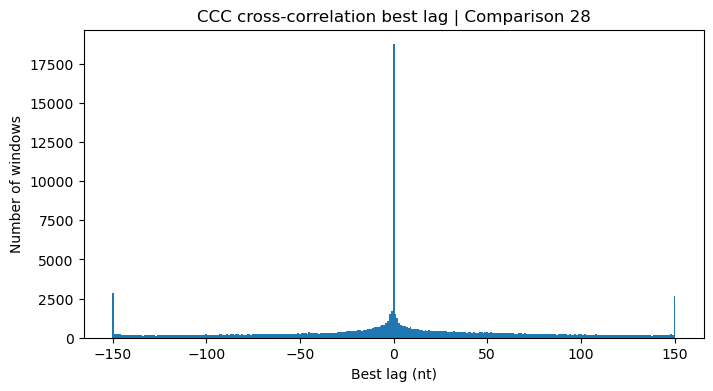

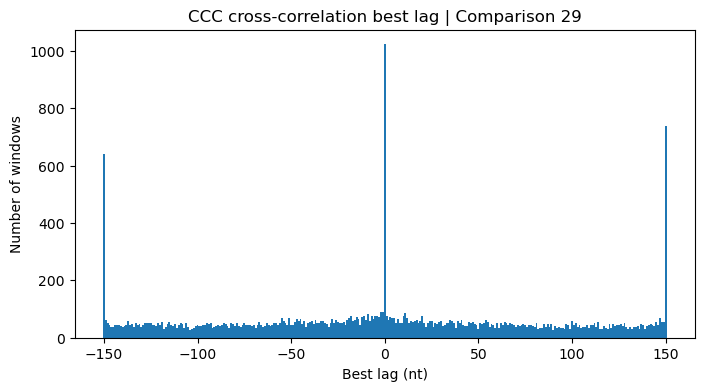

In [8]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(
        group["c17_best_lag"].dropna(),
        bins=np.arange(-150.5, 151.5, 1)
    )

    plt.xlabel("Best lag (nt)")
    plt.ylabel("Number of windows")
    plt.title(f"CCC cross-correlation best lag | Comparison {comparison_id}")
    plt.show()

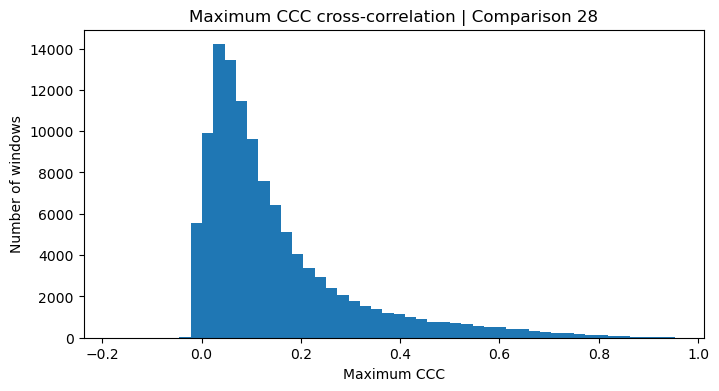

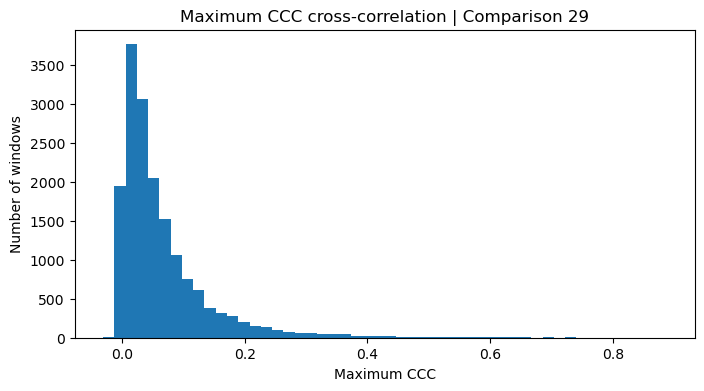

In [9]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(group["c17_max"].dropna(), bins=50)

    plt.xlabel("Maximum CCC")
    plt.ylabel("Number of windows")
    plt.title(f"Maximum CCC cross-correlation | Comparison {comparison_id}")
    plt.show()

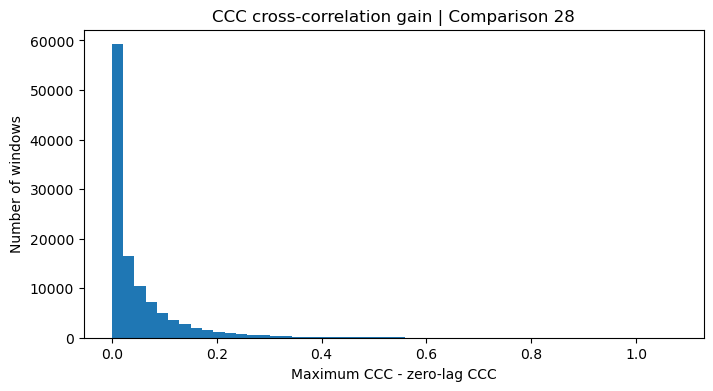

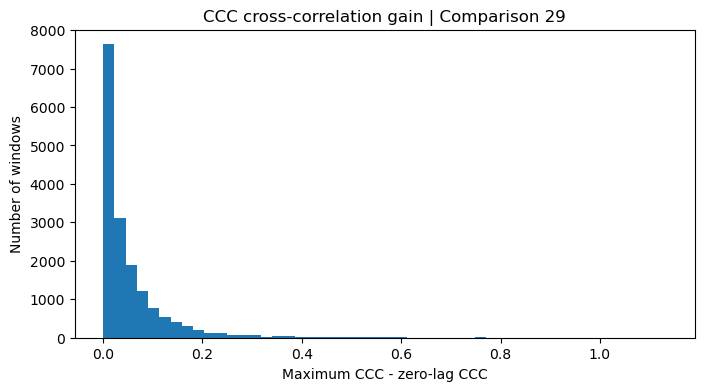

In [10]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(group["c17_gain"].dropna(), bins=50)

    plt.xlabel("Maximum CCC - zero-lag CCC")
    plt.ylabel("Number of windows")
    plt.title(f"CCC cross-correlation gain | Comparison {comparison_id}")
    plt.show()

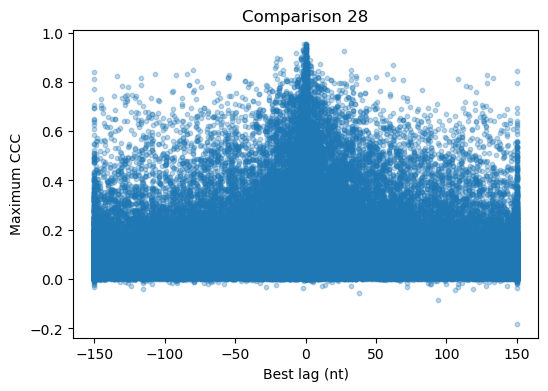

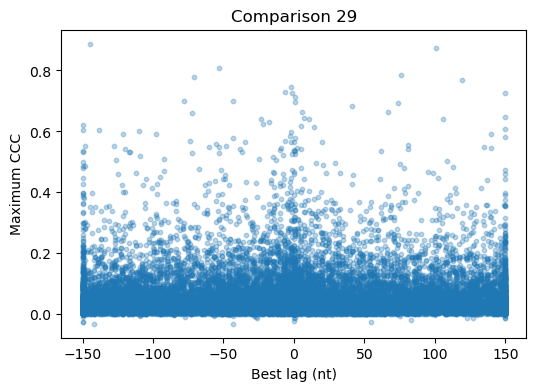

In [11]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(6, 4))
    plt.scatter(
        group["c17_best_lag"],
        group["c17_max"],
        alpha=0.3,
        s=10
    )

    plt.xlabel("Best lag (nt)")
    plt.ylabel("Maximum CCC")
    plt.title(f"Comparison {comparison_id}")
    plt.show()

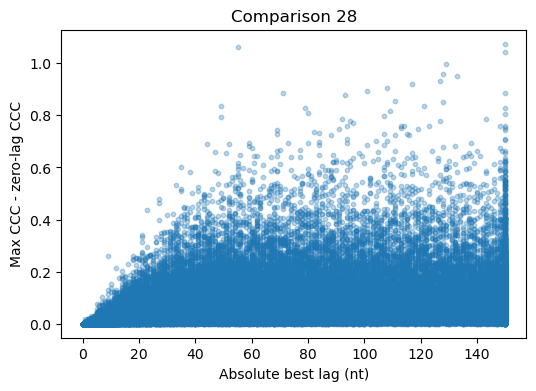

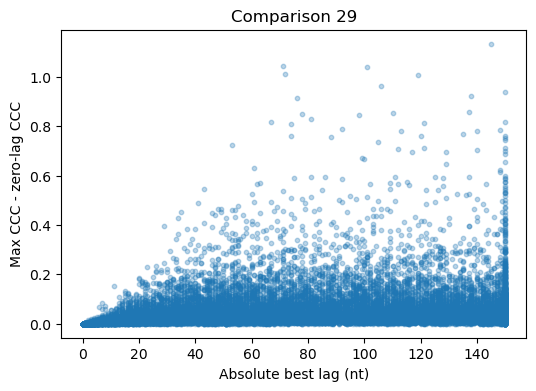

In [12]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(6, 4))
    plt.scatter(
        np.abs(group["c17_best_lag"]),
        group["c17_gain"],
        alpha=0.3,
        s=10
    )

    plt.xlabel("Absolute best lag (nt)")
    plt.ylabel("Max CCC - zero-lag CCC")
    plt.title(f"Comparison {comparison_id}")
    plt.show()

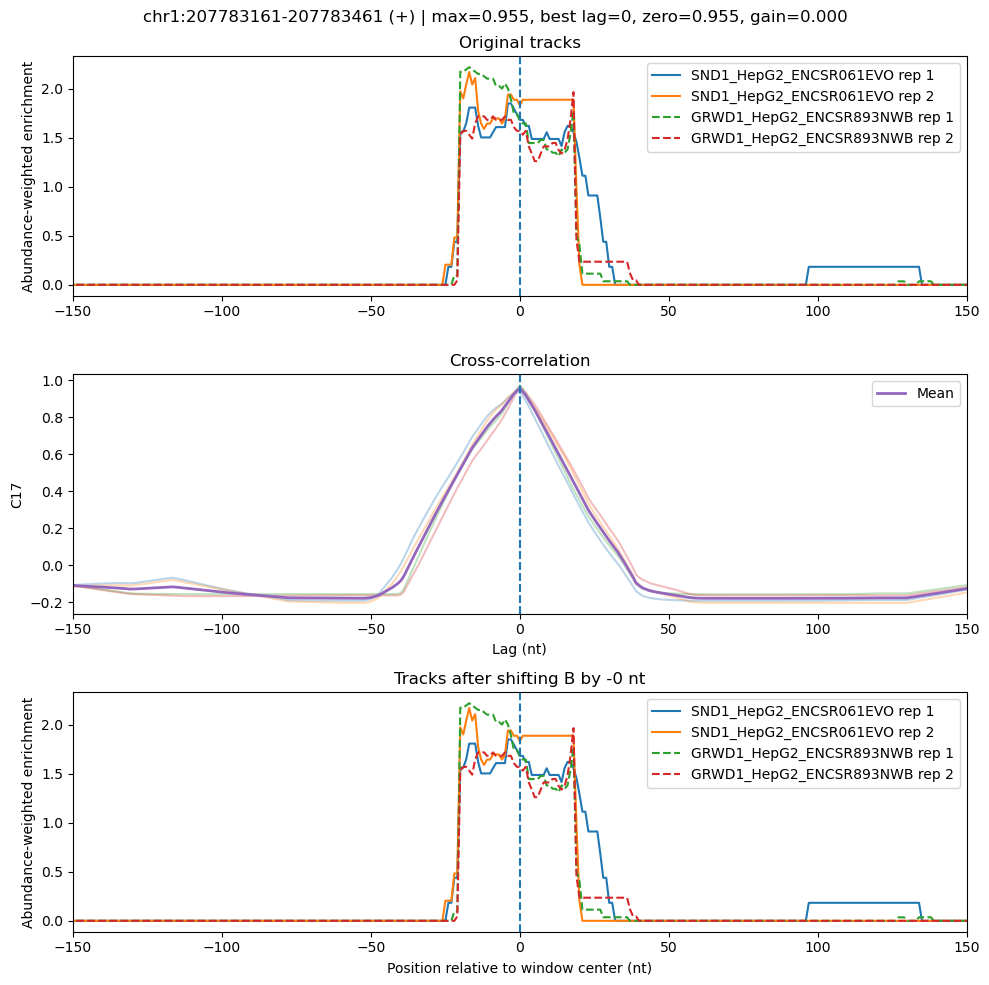

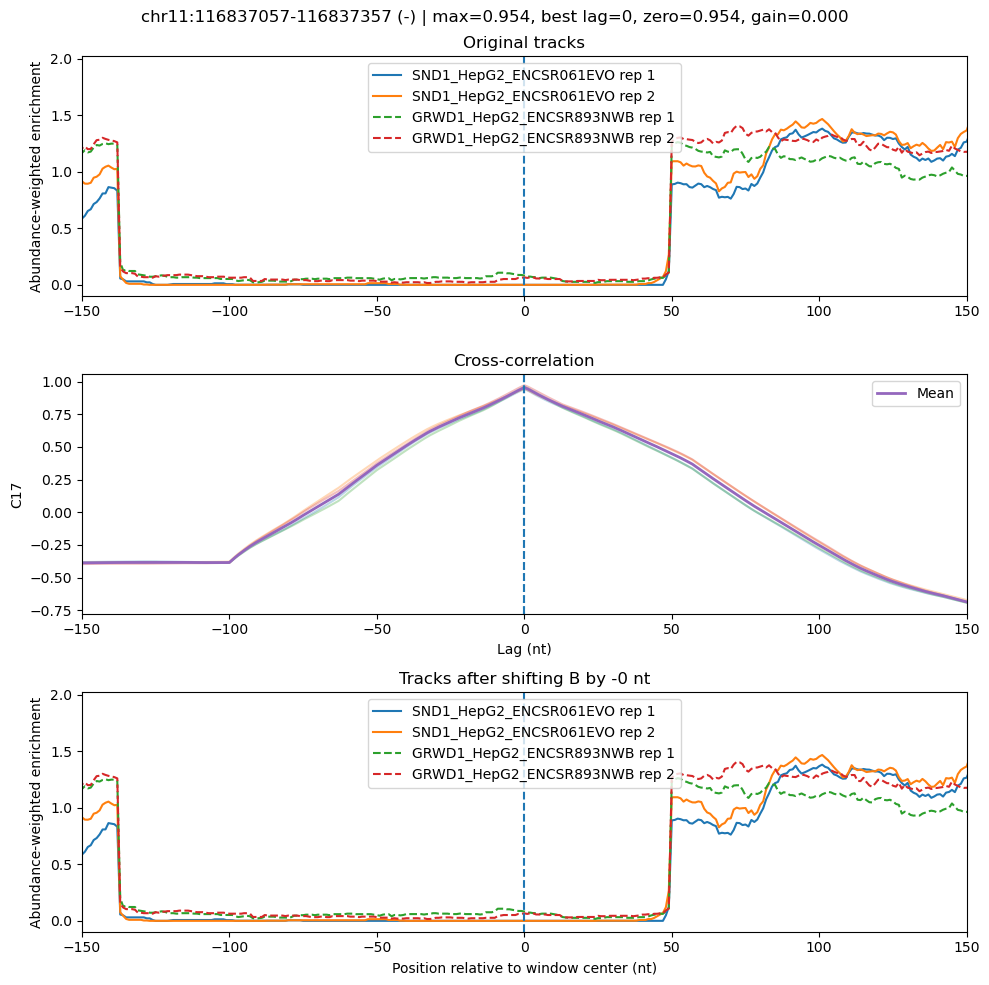

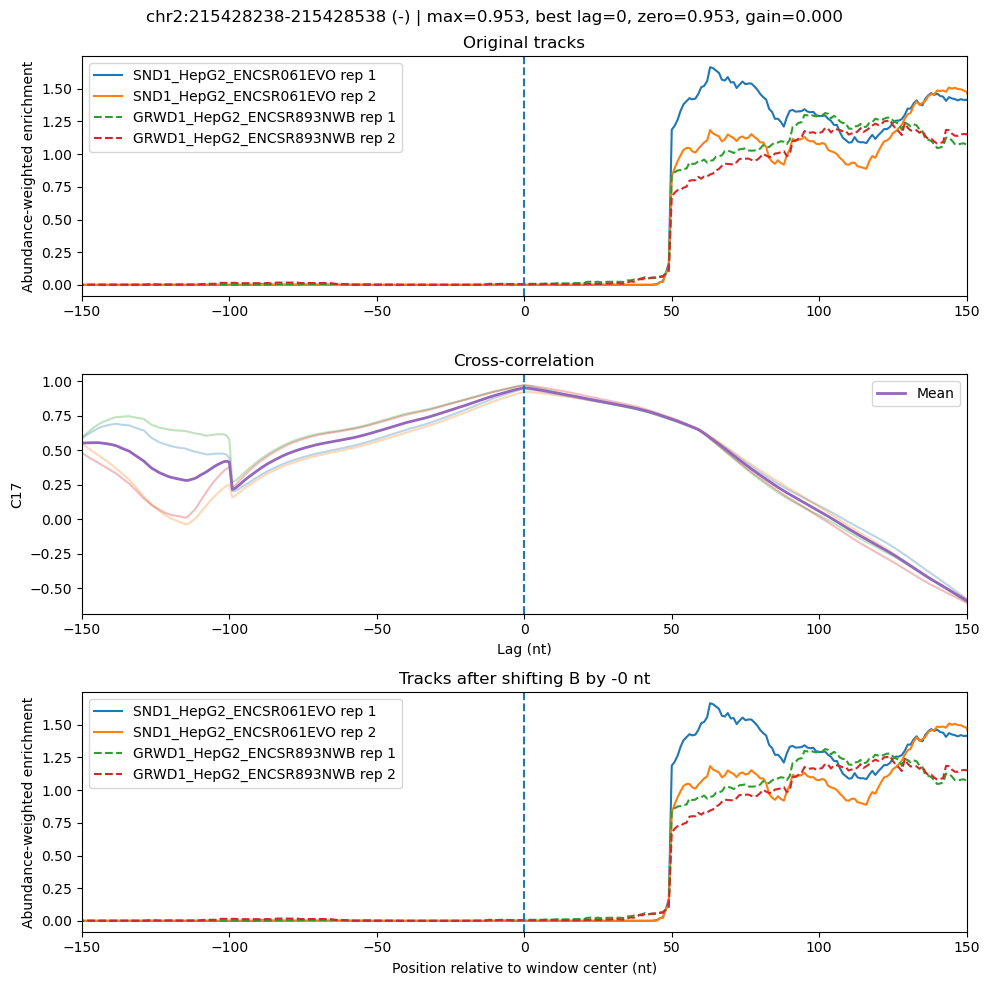

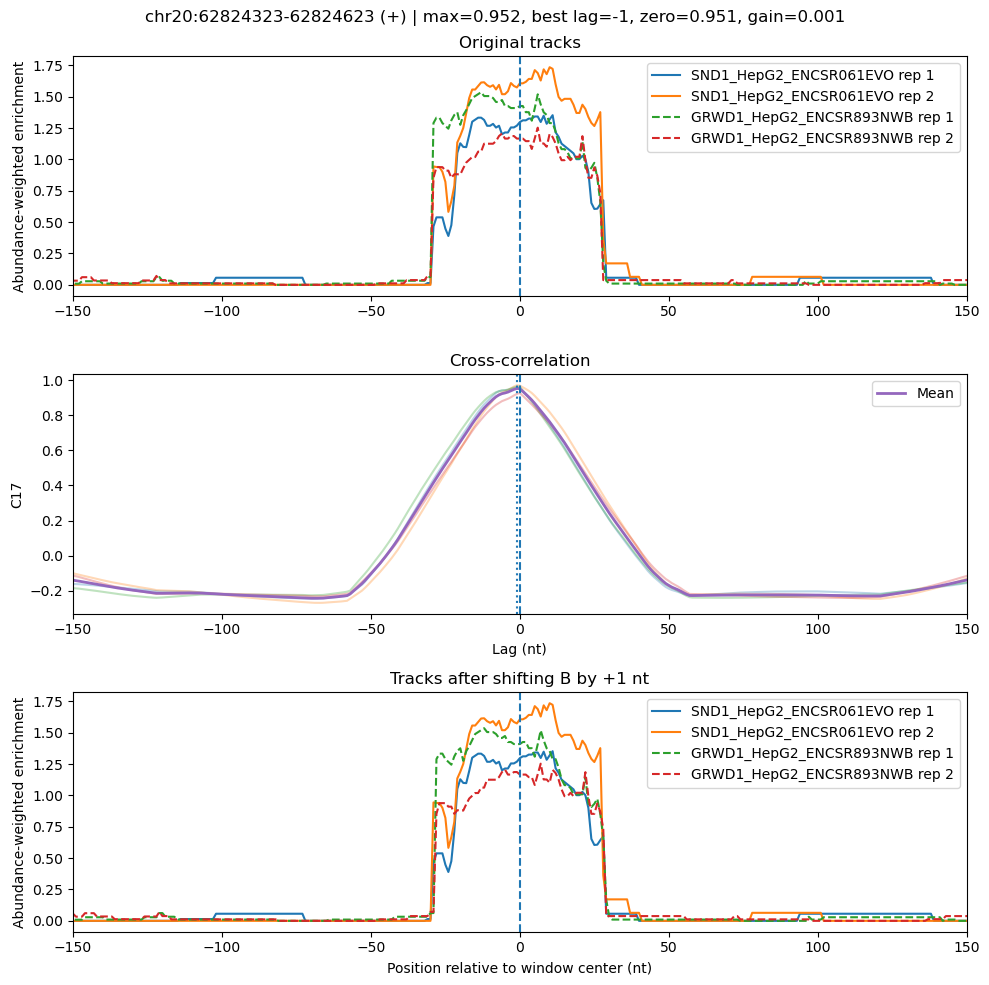

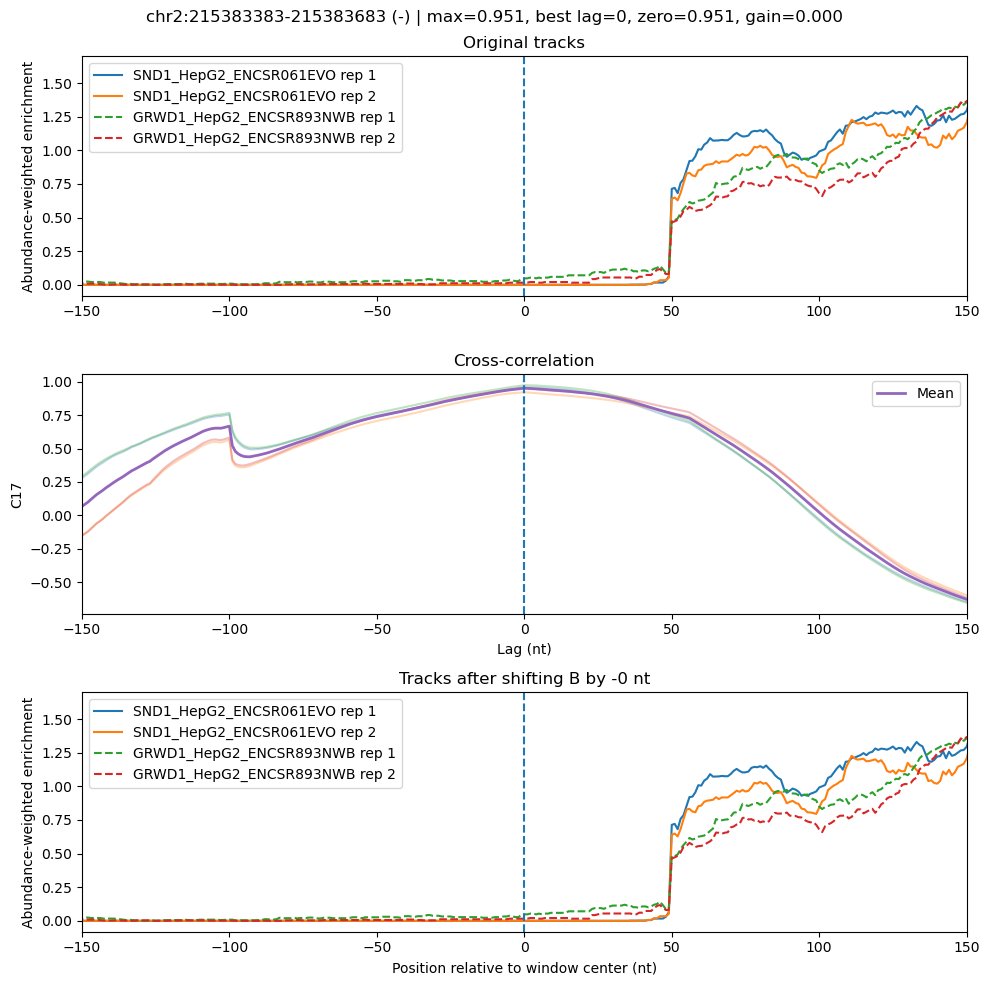

In [13]:
near_zero = metadata[
    metadata["c17_best_lag"].abs() <= 2
].nlargest(5, "c17_max")

for _, row in near_zero.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "c17")

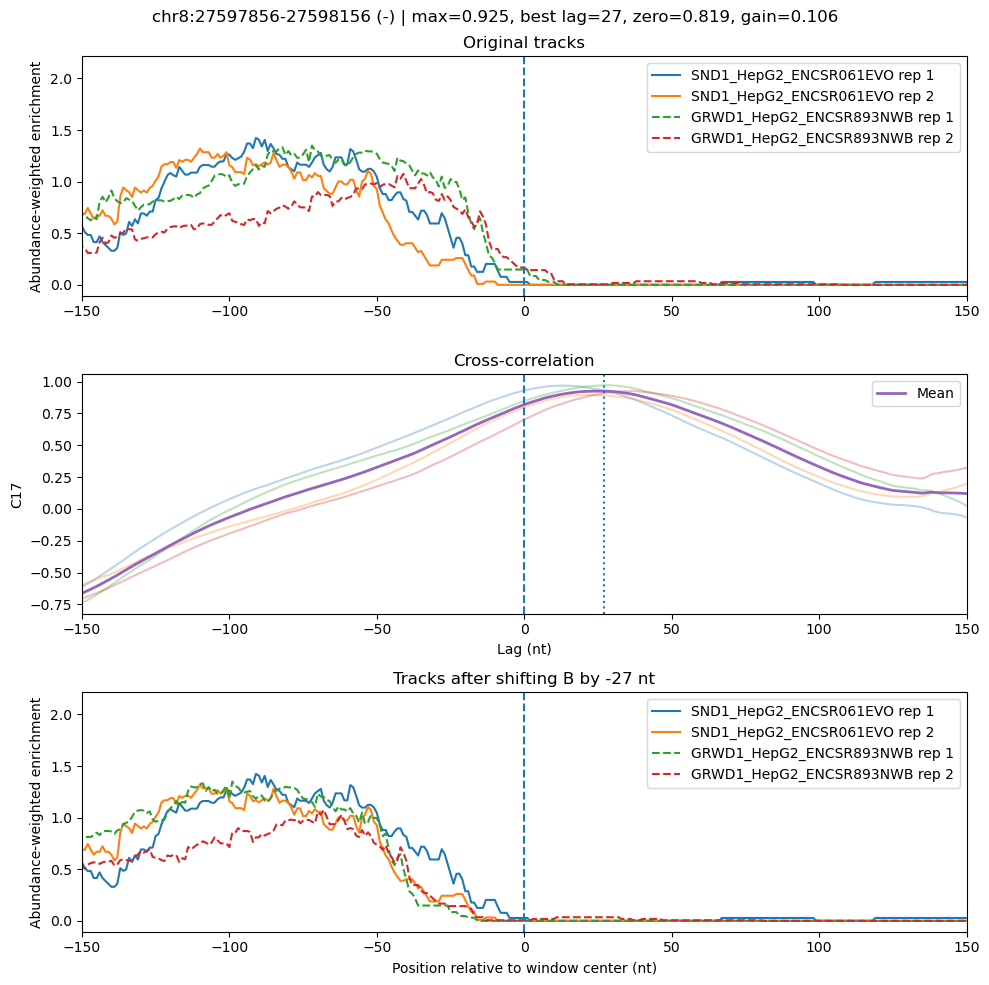

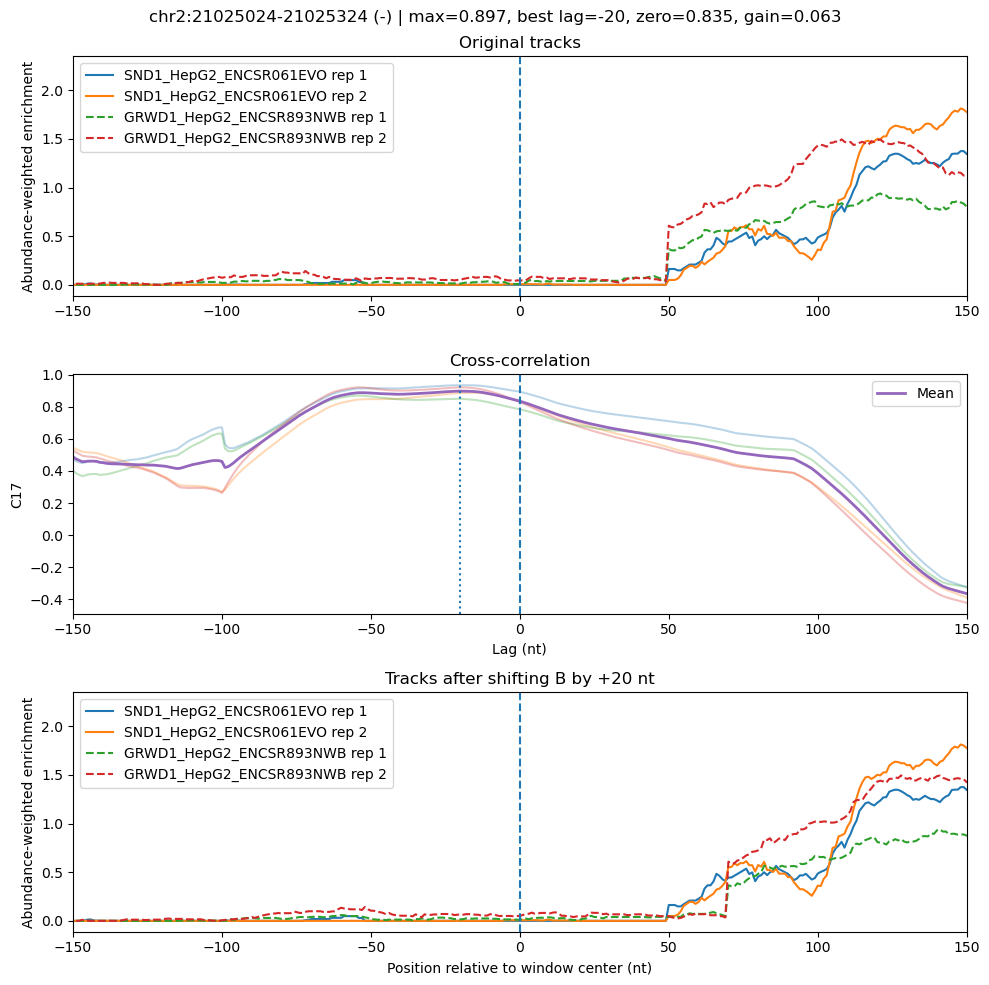

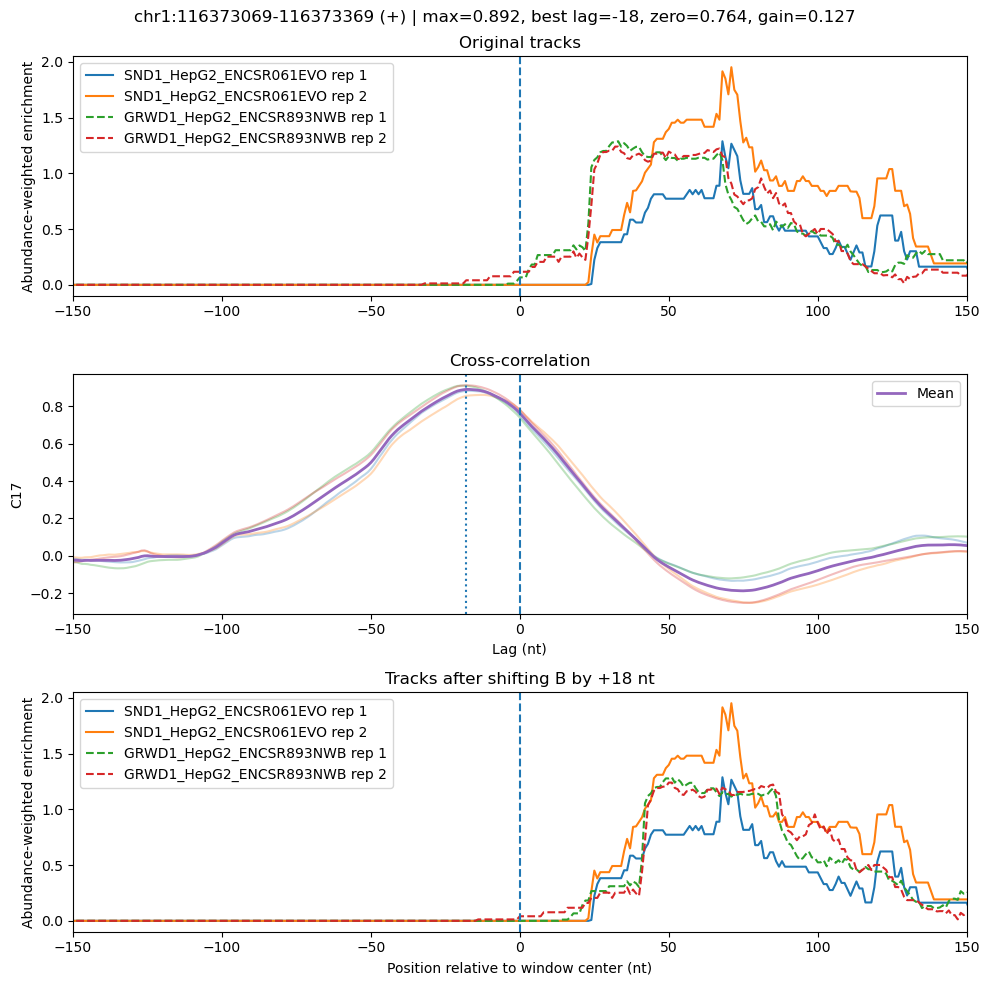

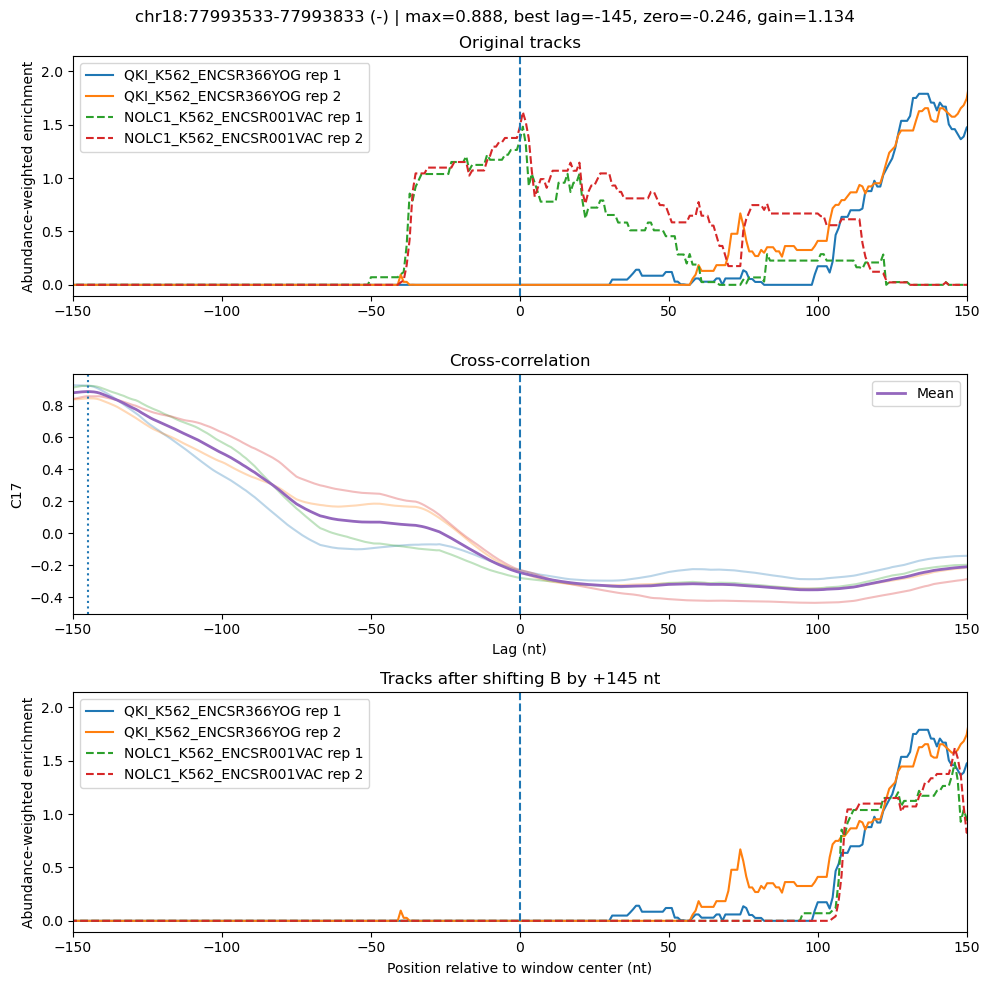

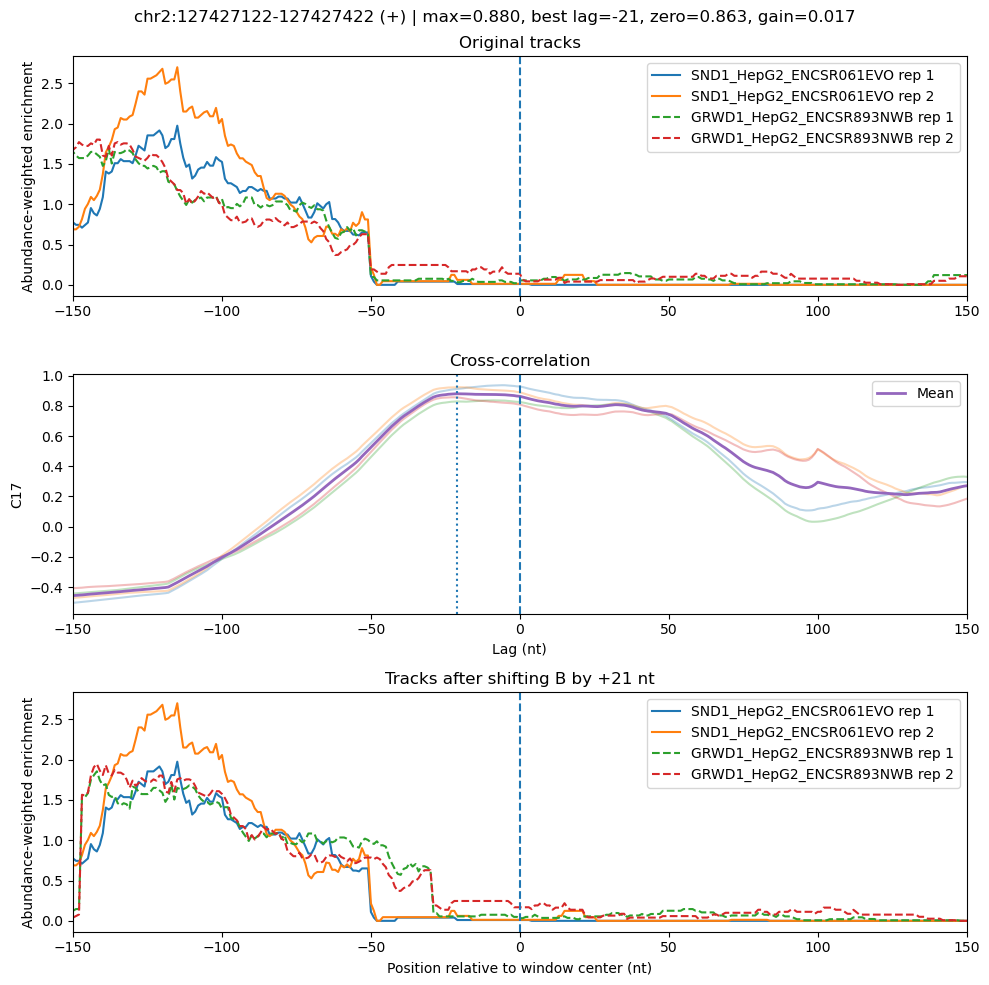

In [14]:
large_lag = metadata[
    metadata["c17_best_lag"].abs() >= 10
].nlargest(5, "c17_max")

for _, row in large_lag.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "c17")

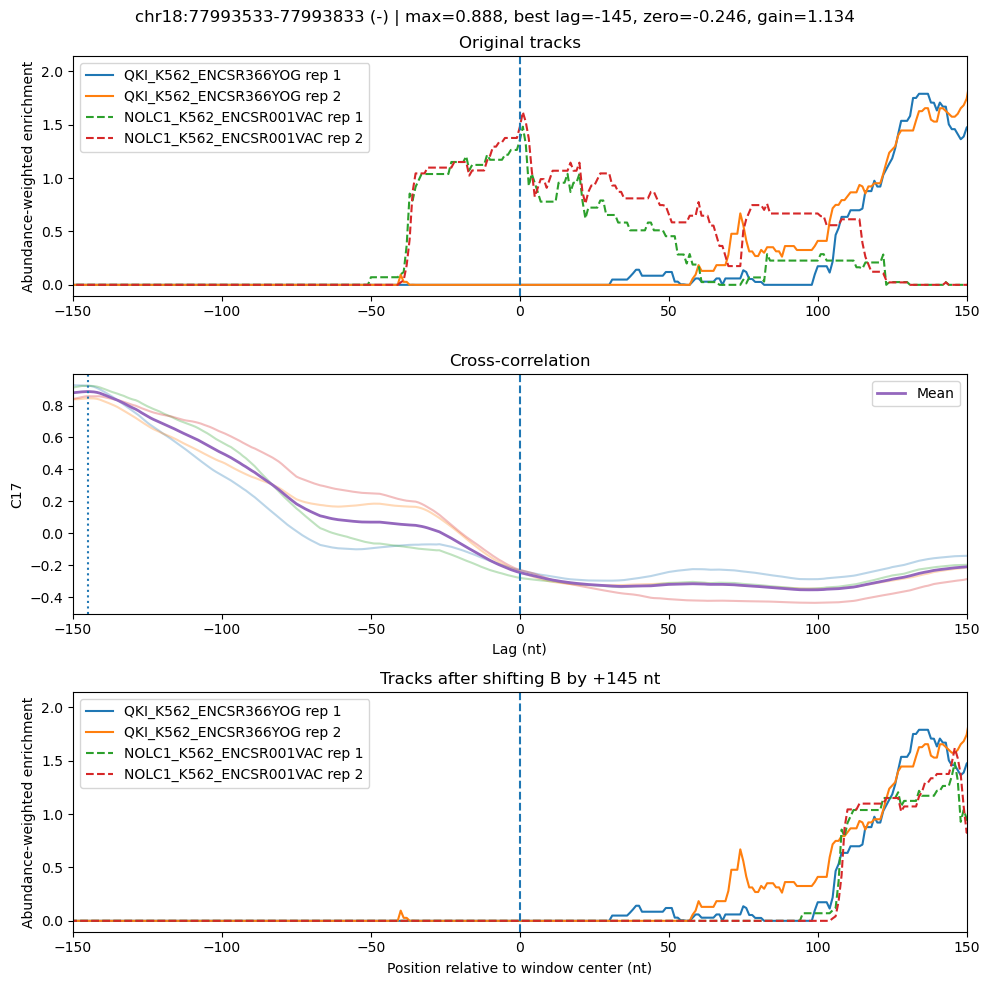

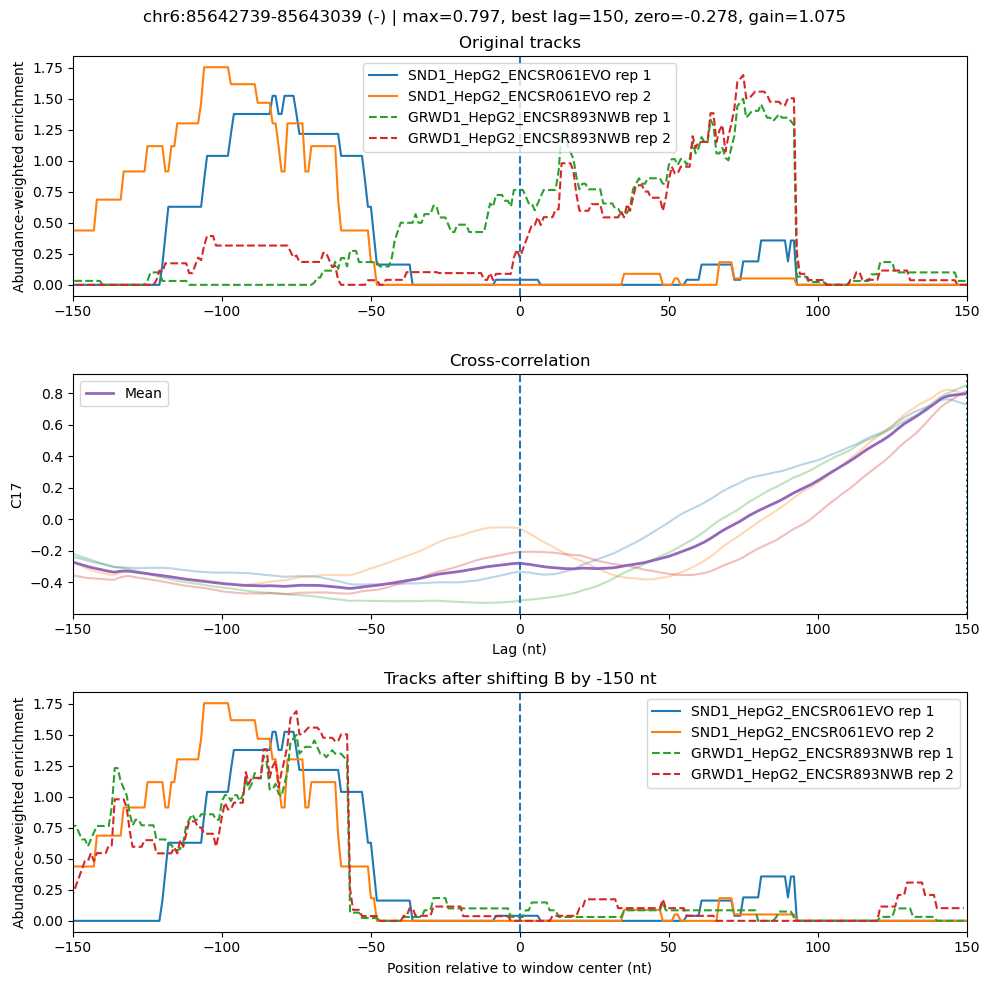

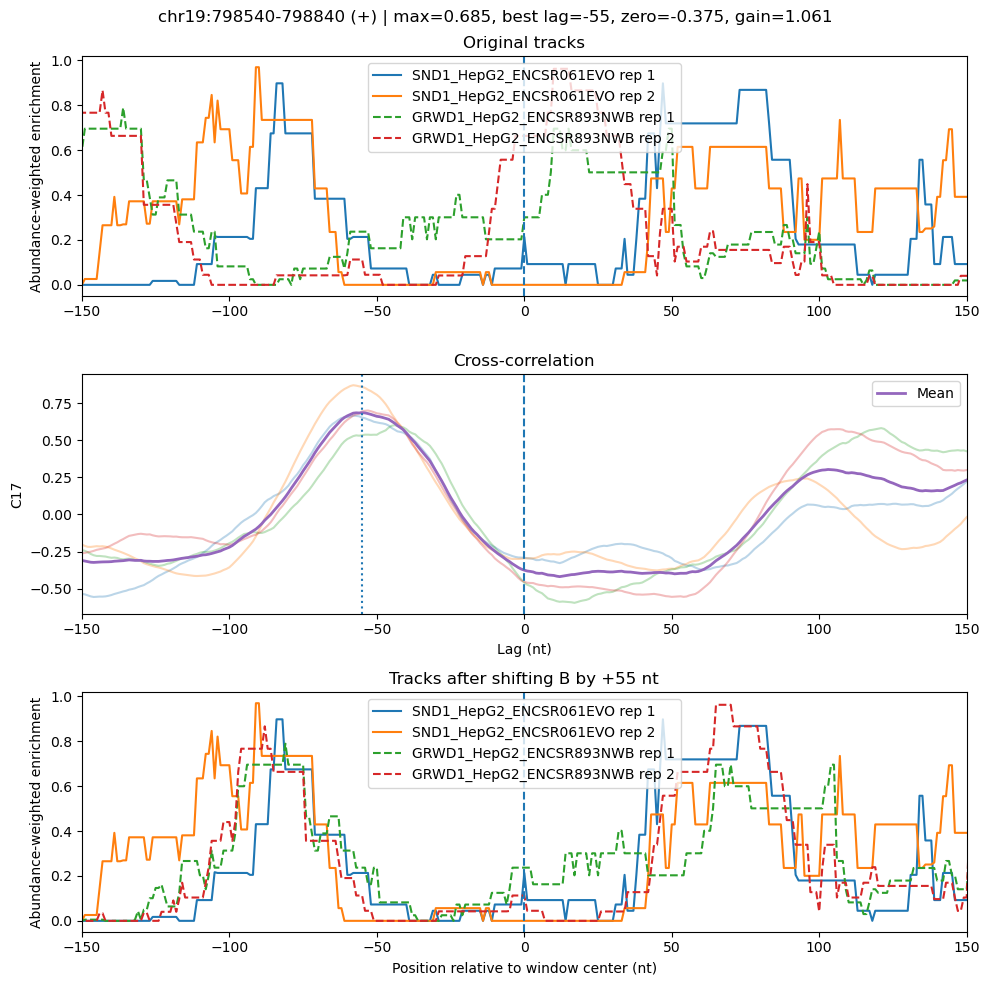

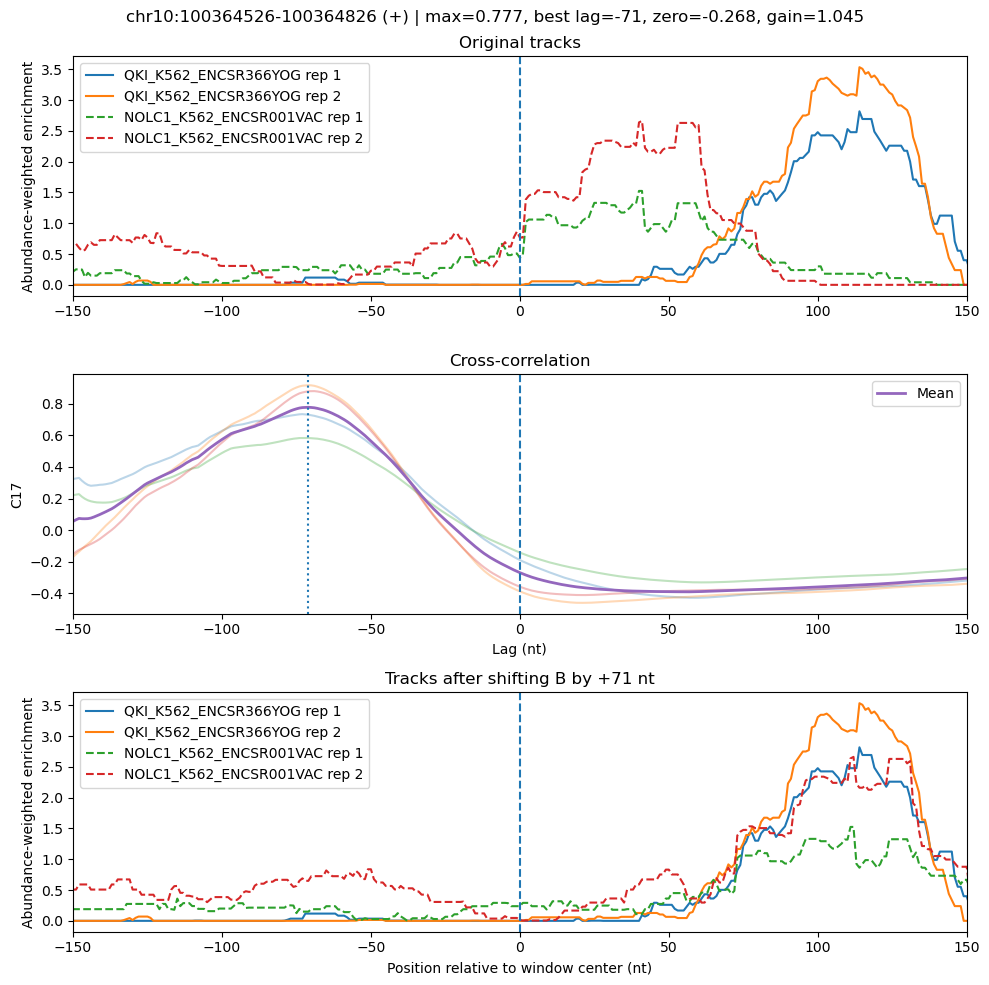

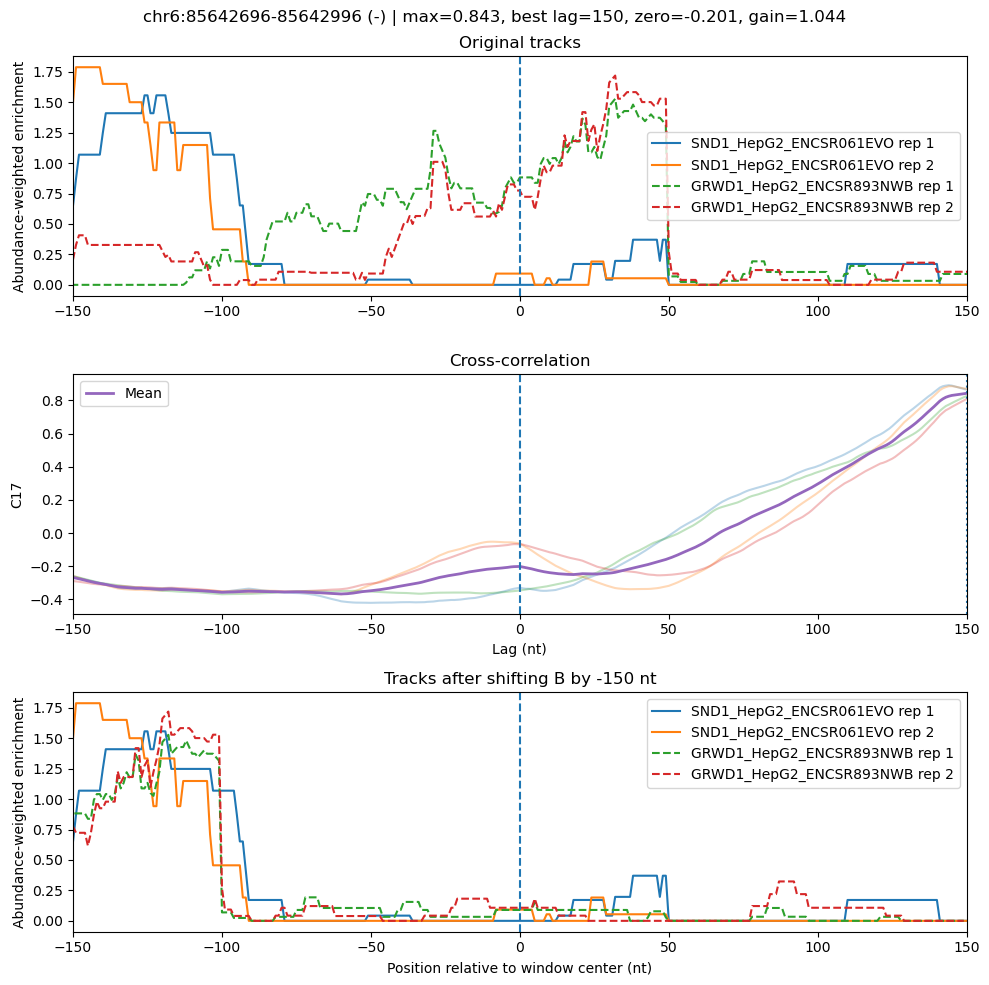

In [15]:
high_gain = metadata.nlargest(5, "c17_gain")

for _, row in high_gain.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "c17")

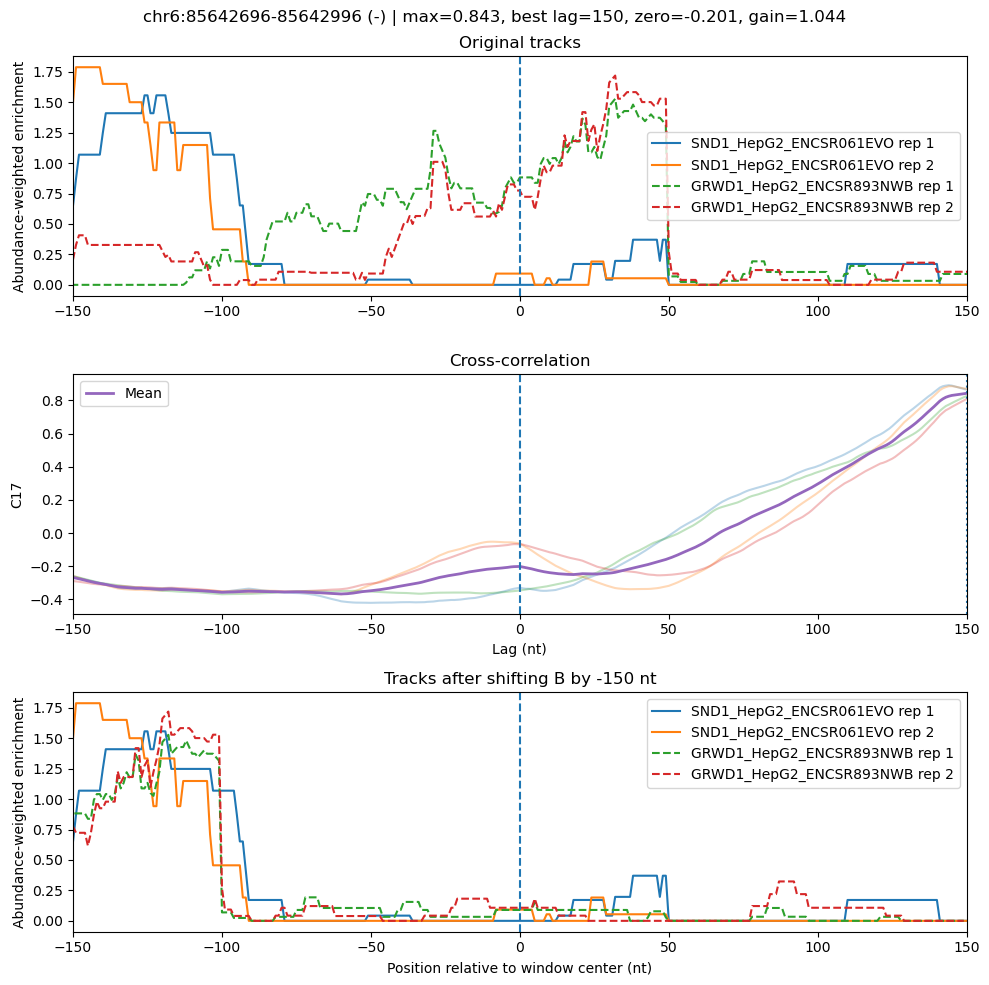

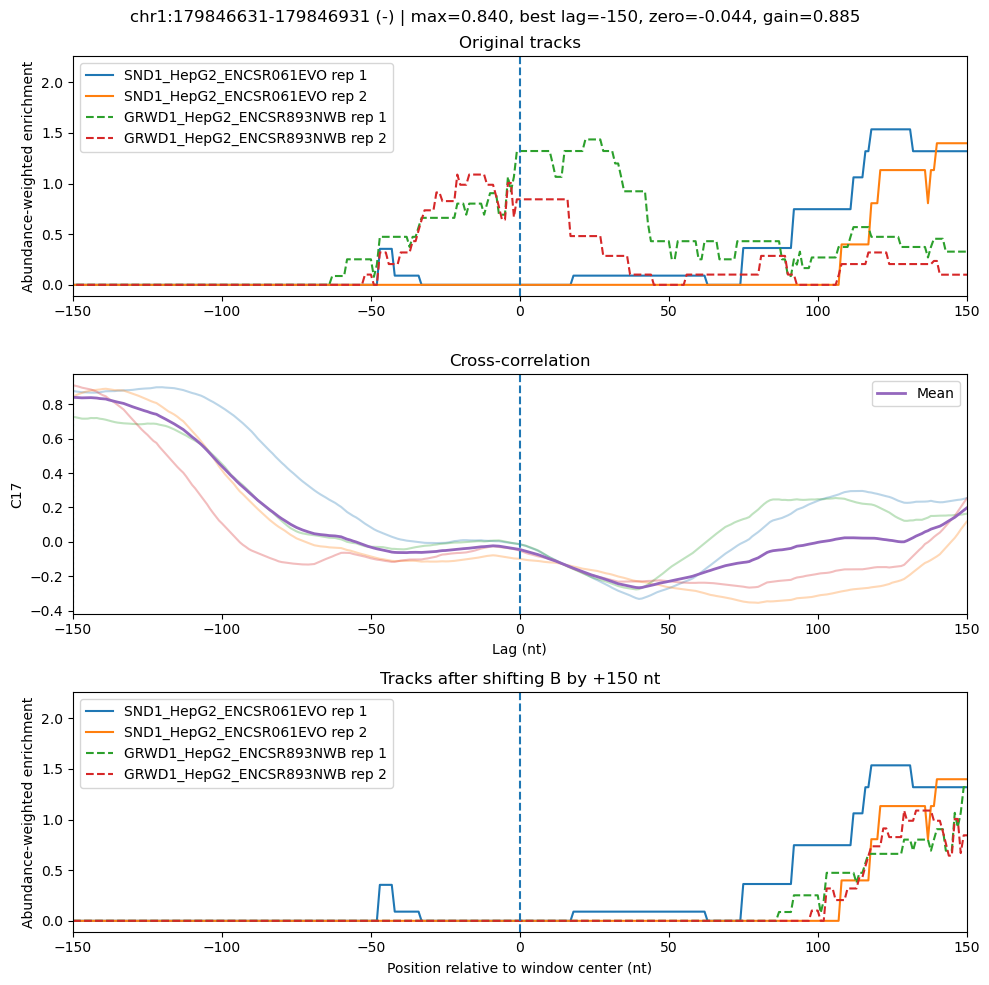

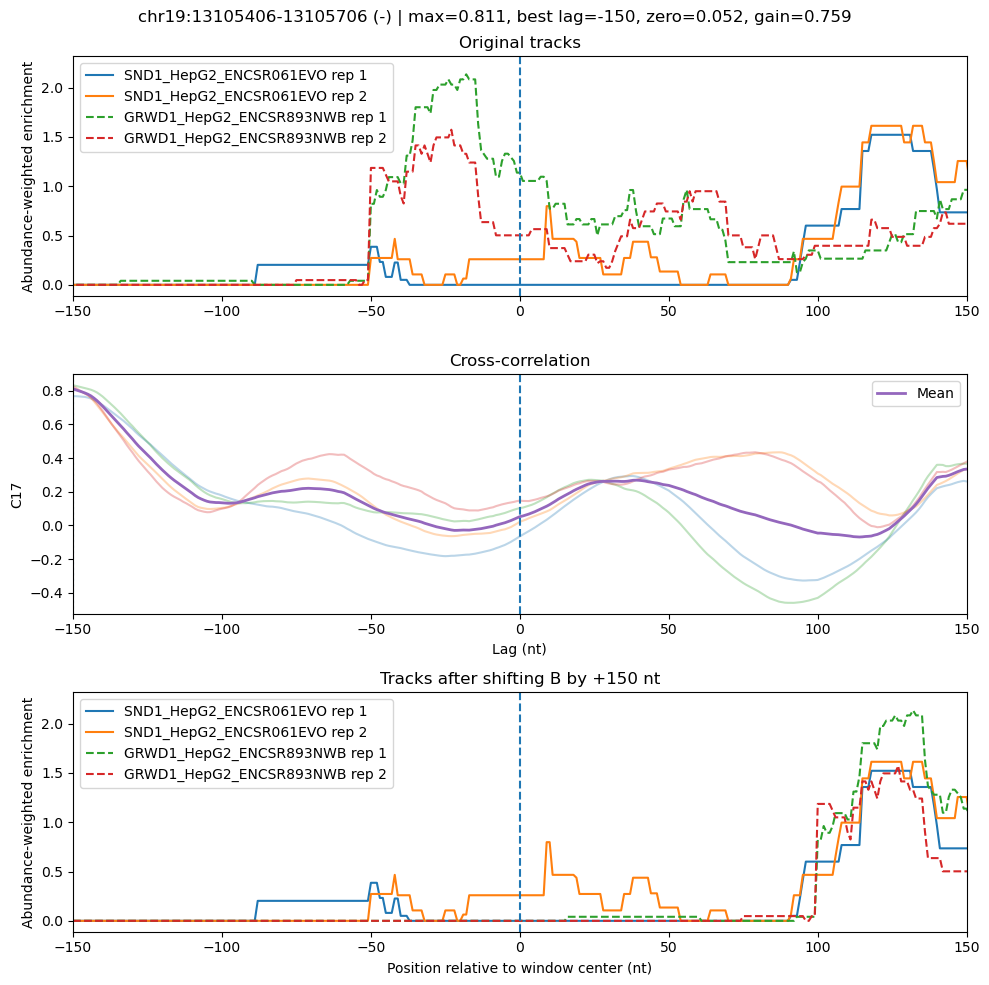

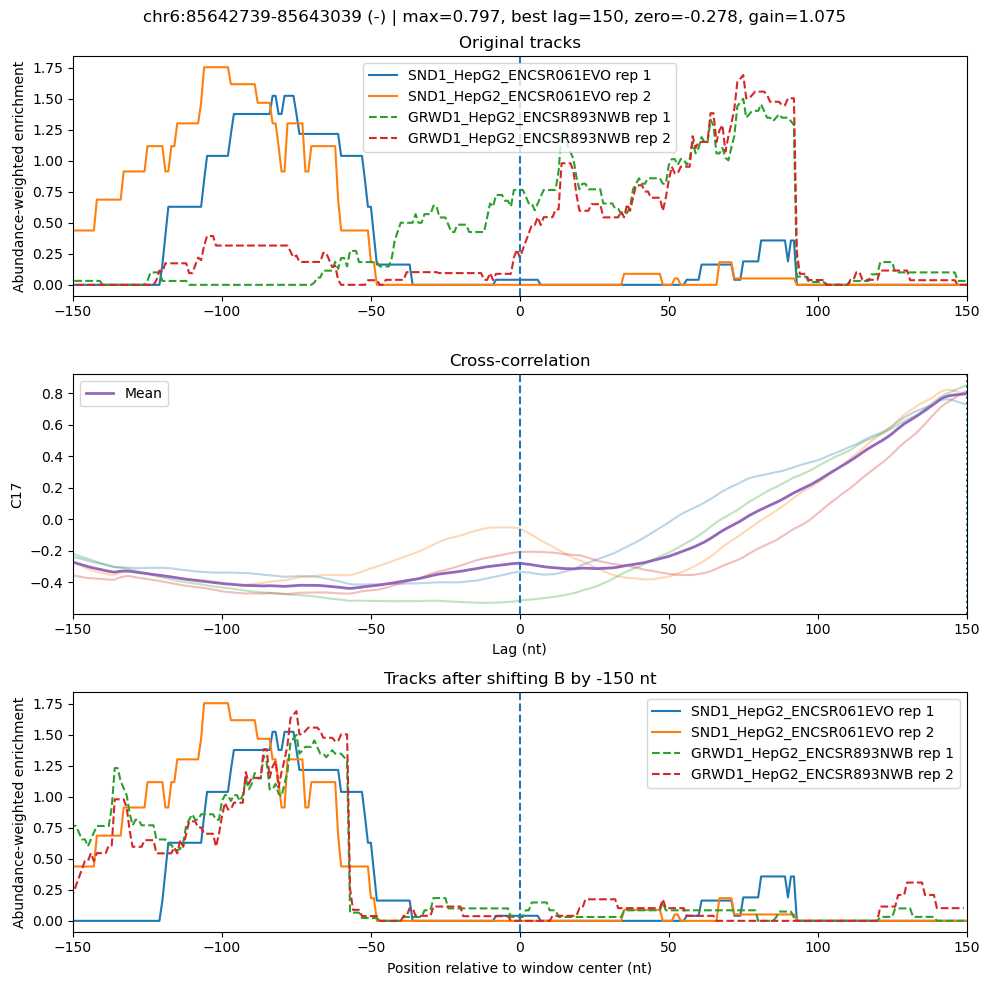

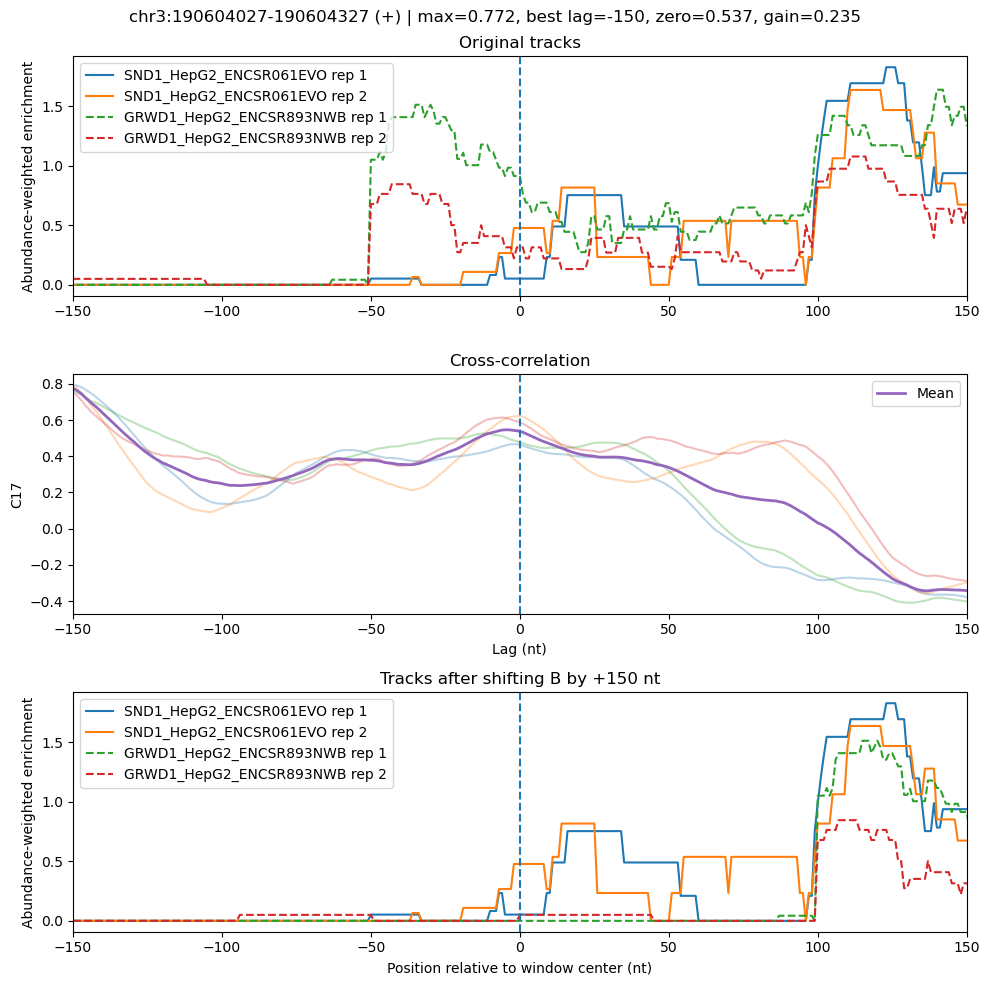

In [16]:
boundary = metadata[
    metadata["c17_best_lag"].abs() == 150
].nlargest(5, "c17_max")

for _, row in boundary.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "c17")

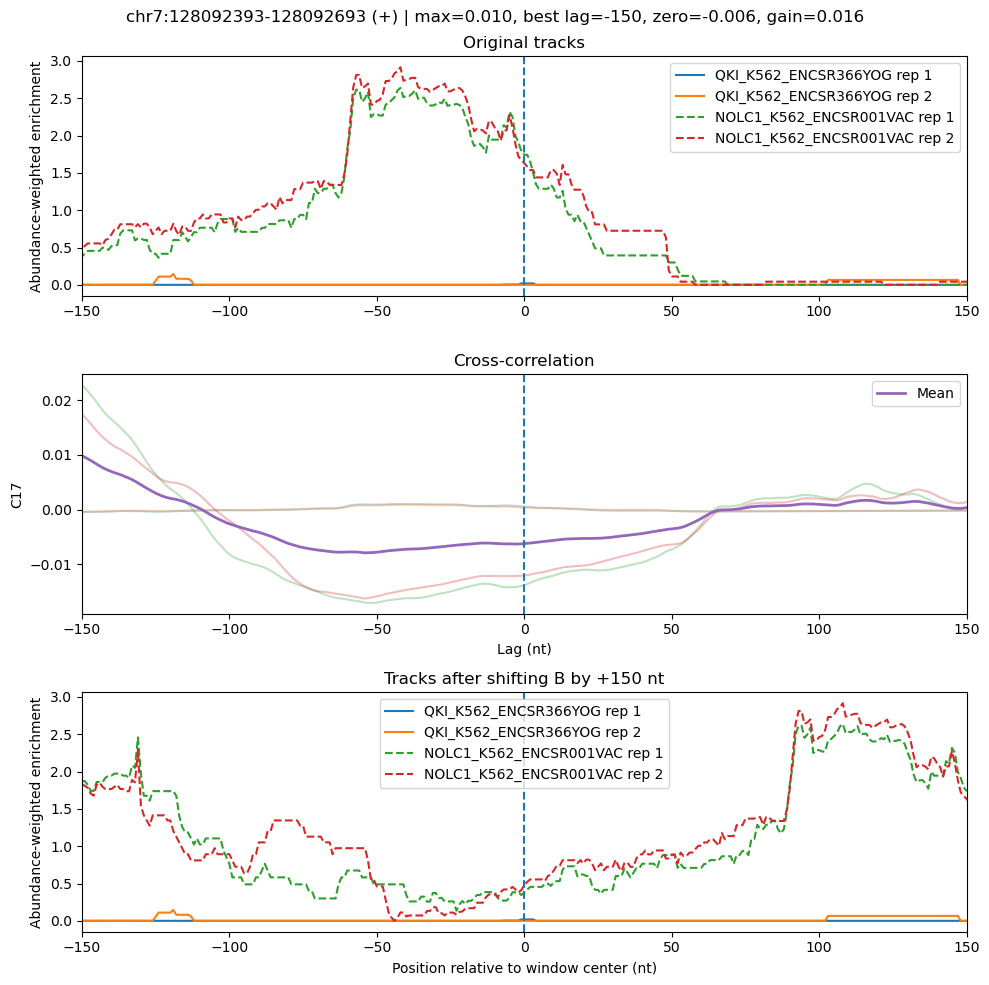

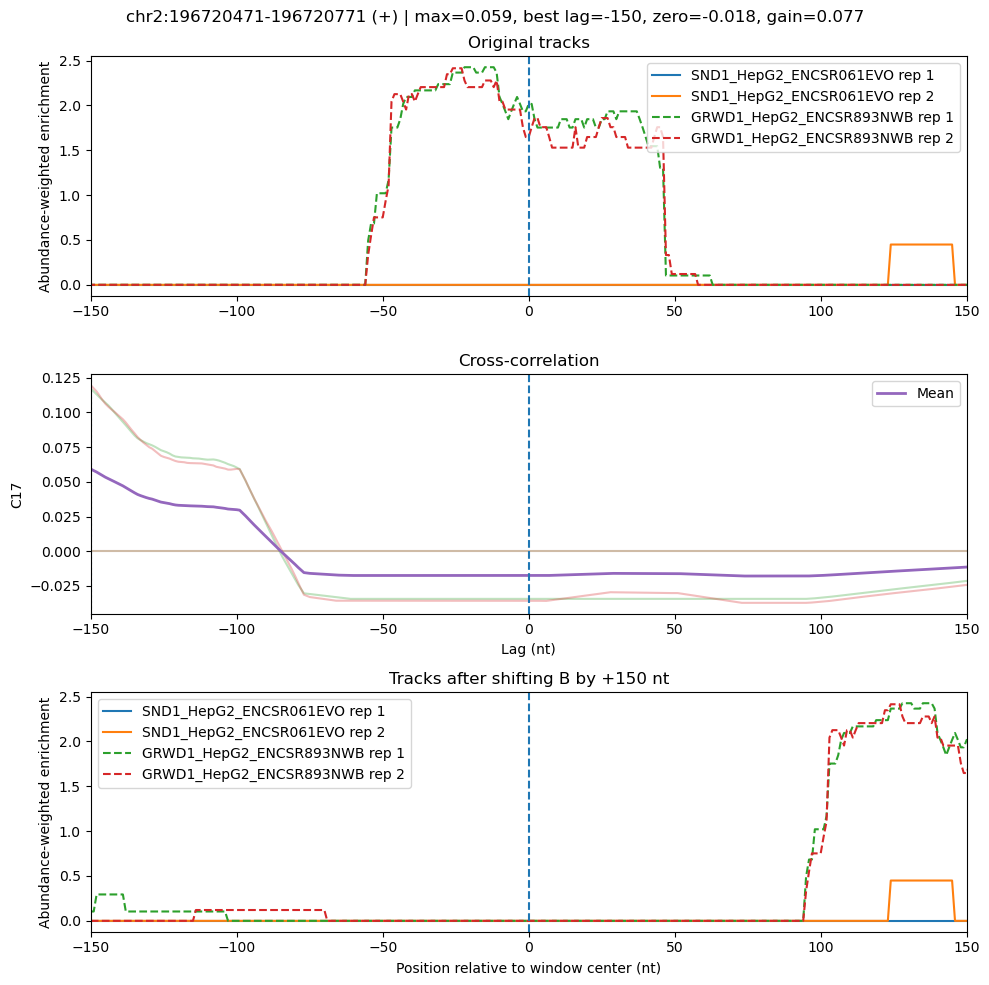

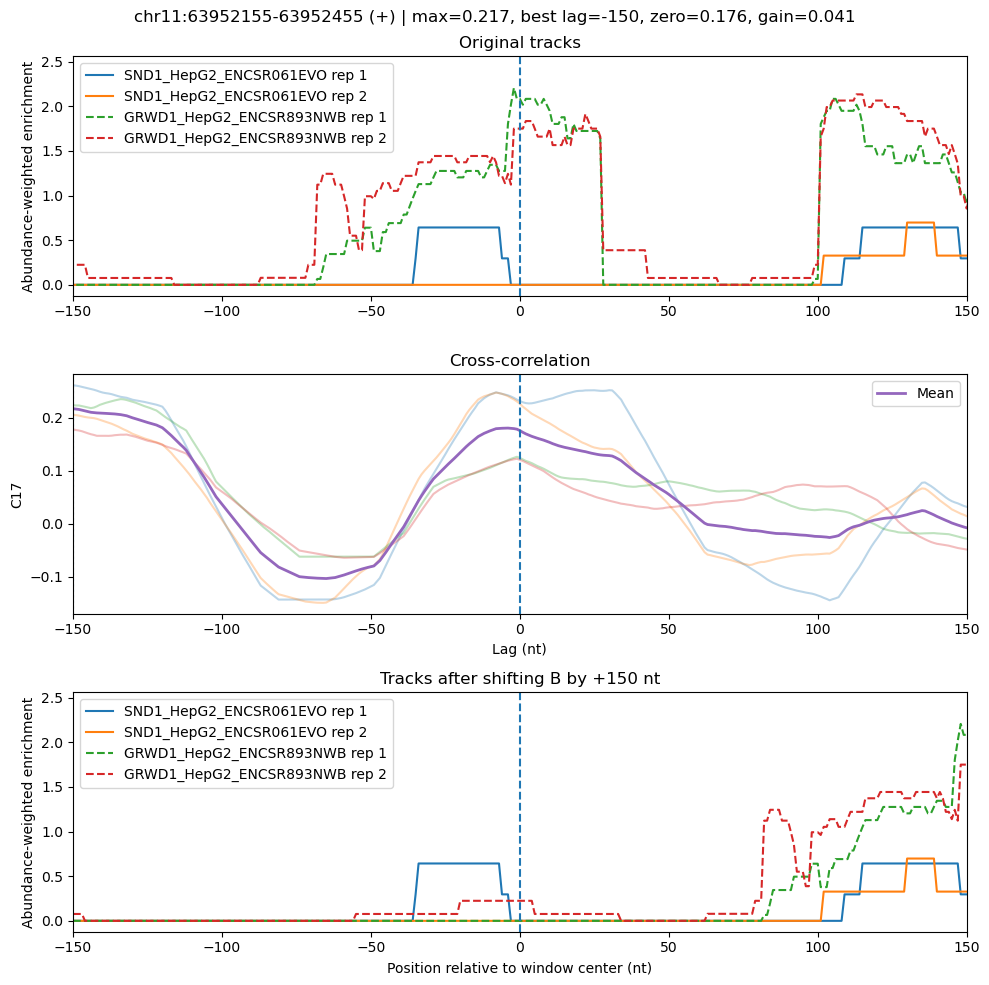

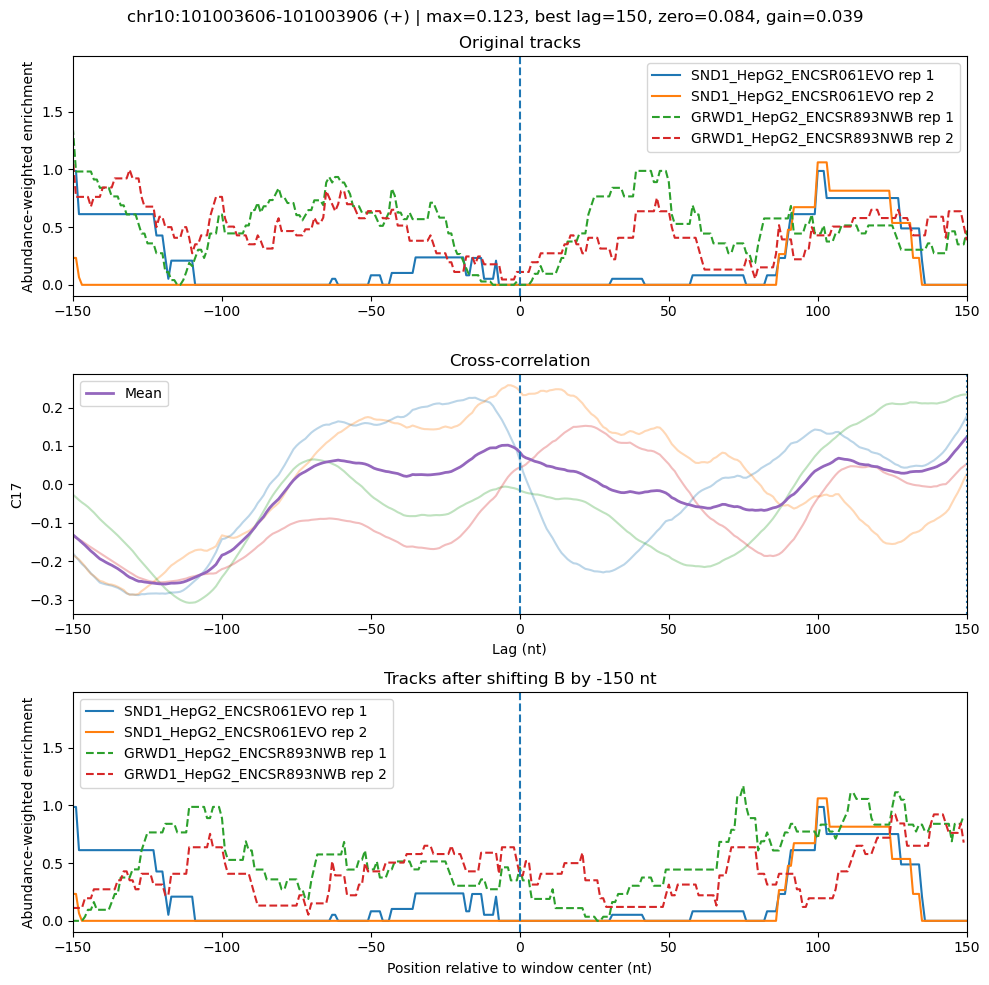

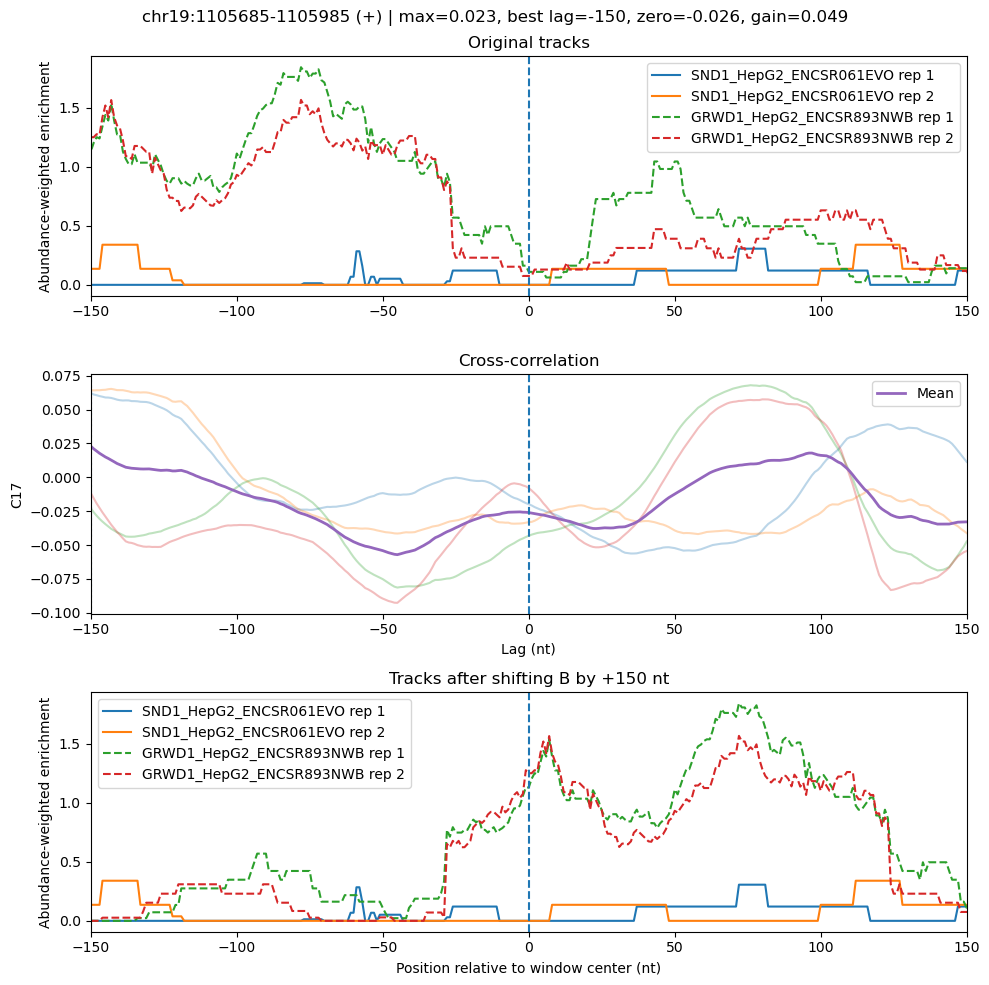

In [17]:
boundary = metadata[
    metadata["c17_best_lag"].abs() == 150
].sample(5, random_state=4)

for _, row in boundary.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "c17")